In [1]:
from pachner_traversal.utils import data_root
import pandas as pd
import matplotlib.pyplot as plt
from typing import cast
import numpy as np
import regina

In [3]:
model_size = {
    "xs": 3_200_512,
    "s": 10_708_992,
    "m": 37_911_552,
    "l": 113_530_368,
}

model_name = {
    "xs": "spheres_256emb_4block_4head_15tet",
    "s": "spheres_384emb_6block_6head_15tet",
    "m": "spheres_512emb_12block_8head_15tet",
    "l": "spheres_768emb_16block_12head_15tet",
    "xl": "spheres_1024emb_24block_16head_15tet",
}

opt_lr = {
    "xs": 3e-3,
    "s": 1e-3,
    "m": 1e-3,
    "l": 1e-3,
}


def get_res_path(lr, size):
    res_path = (
        data_root
        / "results"
        / "sgd_models_dehydration"
        / "scale"
        / f"{size}"
        / f"{lr}"
        / model_name[size]
    )
    return res_path


def read_losses(lr, size):
    res_path = get_res_path(lr, size)
    try:
        train_losses = pd.read_csv(
            res_path / "train_losses.csv",
            header=None,
            index_col=0,
        ).squeeze("columns")
        test_losses = pd.read_csv(
            res_path / "test_losses.csv",
            header=None,
            index_col=0,
        ).squeeze("columns")

        train_losses = cast(pd.Series, train_losses)
        test_losses = cast(pd.Series, test_losses)

        train_losses.index.name = None
        test_losses.index.name = None

        return train_losses, test_losses
    except FileNotFoundError:
        return None, None


def plot(train_losses, test_losses, label, ax, color, size):
    if train_losses is None or test_losses is None:
        return

    ax.plot(
        itt_to_flop(train_losses.index, size),
        train_losses,
        color=color,
        label=f"train loss - {label}",
        ls='--'
    )

    ax.plot(
        itt_to_flop(test_losses.index, size)*1.05,
        test_losses,
        color=color,
        label=f"test loss - {label}",
    )


def get_echar(T: regina.Triangulation3):
    chs = []

    for v in T.vertices():
        chs.append(v.linkEulerChar())

    return sum(chs) / len(chs)


def check_triangulation(iso_sig):
    try:
        T = regina.engine.Triangulation3.rehydrate(iso_sig)
        loads = True
        valid = T.isValid()
        closed = T.isClosed()
        sphere = T.fundamentalGroup().recogniseGroup() == "0"

        echar = get_echar(T)

    except Exception:
        loads = False
        valid = False
        closed = False
        sphere = False
        echar = np.nan

    return loads, valid, closed, sphere, echar


def check_all_triangulations(iso_sigs):
    checks = []

    for i, iso in enumerate(iso_sigs):
        checks.append(check_triangulation(iso))
    loads = [c[0] for c in checks]
    valid = [c[1] for c in checks]
    closed = [c[2] for c in checks]
    sphere = [c[3] for c in checks]
    echars = [c[4] for c in checks]

    return loads, valid, closed, sphere, echars


def run_checks(lr, size, step=None):
    fname = "generated_samples"
    fname = fname + f"_{step:,}.txt" if step is not None else fname + ".txt"

    res_path = get_res_path(lr, size)

    with open(res_path / fname, "r") as f:
        lines = f.readlines()

    iso_sigs = [line.strip() for line in lines]

    return check_all_triangulations(iso_sigs)


def run_all_checks(lr, size):
    # Read steps.
    res_path = get_res_path(lr, size)

    steps = []

    for f in res_path.iterdir():
        if f.name.startswith("generated_samples_"):
            step_str = f.name
            step_str = step_str.replace("generated_samples_", "")
            step_str = step_str.replace(".txt", "")
            step_str = step_str.replace(",", "")

            steps.append(int(step_str))

    steps.sort()

    # Run checks.
    hist_loads = {}
    hist_valid = {}
    hist_closed = {}
    hist_sphere = {}
    hist_echars = {}

    for step in steps:
        print(f"{step:<7,}", end="\r", flush=True)
        loads, valid, closed, sphere, echars = run_checks(lr, size, step)
        hist_loads[step] = np.sum(loads) / len(loads)
        hist_valid[step] = np.sum(valid) / len(valid)
        hist_closed[step] = np.sum(closed) / len(closed)
        hist_sphere[step] = np.sum(sphere) / len(sphere)
        if np.all(np.isnan(echars)):
            hist_echars[step] = np.nan
        else:
            hist_echars[step] = np.nanmean(echars)

    hist_loads, hist_valid, hist_closed, hist_sphere, hist_echars = (
        pd.Series(hist_loads),
        pd.Series(hist_valid),
        pd.Series(hist_closed),
        pd.Series(hist_sphere),
        pd.Series(hist_echars),
    )

    return hist_loads, hist_valid, hist_closed, hist_sphere, hist_echars


def itt_to_flop(idx, size):
    return idx * 6 * model_size[size] * (41 * 512)

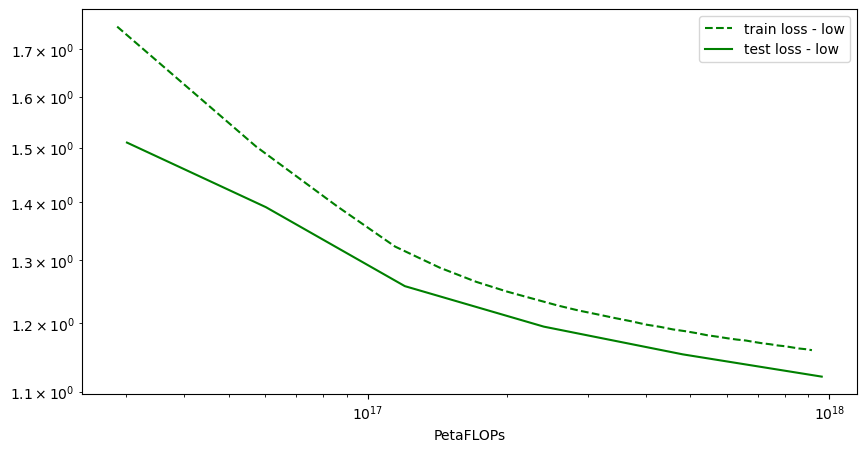

In [4]:
fig, ax = plt.subplots(figsize=(10, 5))

train_losses_xlow, test_losses_xlow = read_losses(3e-4, "m")
train_losses_low, test_losses_low = read_losses(1e-3, "m")
train_losses_med, test_losses_med = read_losses(3e-3, "m")
train_losses_high, test_losses_high = read_losses(1e-2, "m")

# plot(train_losses_xlow, test_losses_xlow, "xlo", ax, "lime", "s")
plot(train_losses_low, test_losses_low, "low", ax, "green", "m")
# plot(train_losses_med, test_losses_med, "med", ax, "blue", "m")
# plot(train_losses_high, test_losses_high, "high", ax, "orange")

plt.xlabel("PetaFLOPs")

plt.legend()
plt.loglog()

plt.show()

In [5]:
# Scaling laws

In [140]:
_, test_losses_xs = read_losses(opt_lr["xs"], "xs")
_, test_losses_s = read_losses(opt_lr["s"], "s")
_, test_losses_m = read_losses(opt_lr["m"], "m")
_, test_losses_l = read_losses(opt_lr["l"], "l")

KeyError: 'xs'

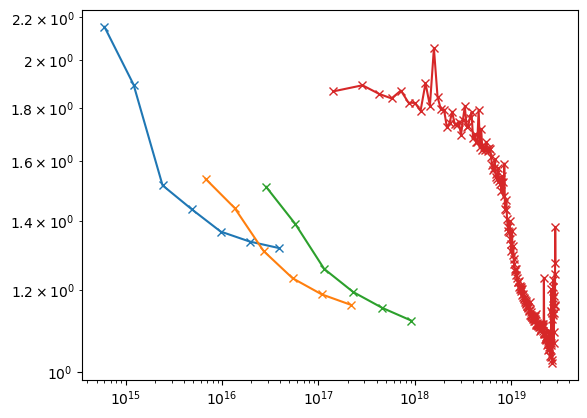

In [137]:
assert test_losses_xs is not None
assert test_losses_s is not None
assert test_losses_m is not None
assert test_losses_l is not None

plt.plot(itt_to_flop(test_losses_xs.index, "xs"), test_losses_xs, marker="x")
plt.plot(itt_to_flop(test_losses_s.index, "s"), test_losses_s, marker="x")
plt.plot(itt_to_flop(test_losses_m.index, "m"), test_losses_m, marker="x")
plt.plot(itt_to_flop(test_losses_l.index.astype(float), "l"), test_losses_l, marker='x')


plt.loglog()
plt.show()

In [65]:
test_losses_xs.index[-2] * 512 * 41 / model_size["xs"]

np.float64(157.41481362981924)

In [67]:
test_losses_s.index[2] * 512 * 41 / model_size["s"]

np.float64(39.20443679479824)

In [30]:
### Check generated samples

In [23]:
hist_loads_xs, hist_valid_xs, hist_closed_xs, hist_sphere_xs, hist_echars_xs = (
    run_all_checks(opt_lr["xs"], "xs")
)
hist_loads_s, hist_valid_s, hist_closed_s, hist_sphere_s, hist_echars_s = (
    run_all_checks(opt_lr["s"], "s")
)
hist_loads_m, hist_valid_m, hist_closed_m, hist_sphere_m, hist_echars_m = (
    run_all_checks(opt_lr["m"], "m")
)
# hist_loads_l, hist_valid_l, hist_closed_l, hist_sphere_l, hist_echars_l = (
#     run_all_checks(opt_lr["l"], "l")
# )

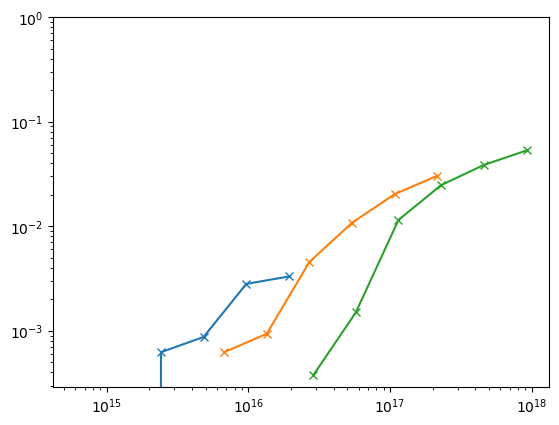

In [35]:
plt.plot(itt_to_flop(hist_sphere_xs.index, "xs"), hist_sphere_xs, marker="x")
plt.plot(itt_to_flop(hist_sphere_s.index, "s"), hist_sphere_s, marker="x")
plt.plot(itt_to_flop(hist_sphere_m.index, "m"), hist_sphere_m, marker="x")
# plt.plot(itt_to_flop(hist_sphere_l.index, "l"), hist_sphere_l)

plt.loglog()
plt.ylim(None, 1)

plt.show()

In [77]:
ar_data_root = (data_root / "results" / "sgd_models_dehydration" / "aspect_ratio_scale")

In [122]:
losses = {}
for lr in [3e-3, 6e-3, 1e-2]:
    losses[lr] = {}
    for model in (ar_data_root / f"{lr}").iterdir():
        loss = pd.read_csv(
            model / "train_losses.csv", index_col=0, header=None
        ).squeeze()
        with open(model / "stats.txt", "r") as f:
            params = int(
                f.readlines()[0].strip().split("n_params, ")[1].replace(",", "")
            )

        loss.index = loss.index * params
        ar = int(
            int(model.name.split("_")[1].replace("emb", ""))
            / int(model.name.split("_")[2].replace("block", ""))
        )
        losses[lr][ar] = loss

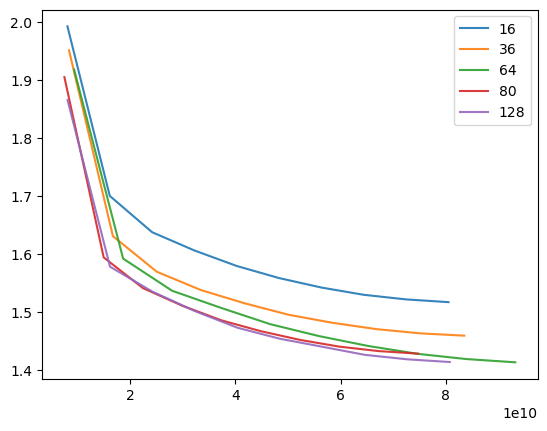

In [124]:
opt_lr = {16: 0.01, 36: 0.006, 64: 0.006, 80: 0.006, 128: 0.01}

for k in [16, 36, 64, 80, 128]:
    plt.plot(losses[opt_lr[k]][k], alpha=0.9, label=k)

# plt.loglog()
plt.legend()
plt.show()

In [9]:
import pandas as pd
import numpy as np

In [72]:
tdf = pd.read_clipboard(thousands=',')

KeyboardInterrupt: 

In [81]:
C = 3e16

X = np.log(tdf[tdf["FLOPS"] == C]["n_params"].values)
y = tdf[tdf["FLOPS"] == C]["test_loss"].values

res = np.polyfit(X, y, 2)
opt_params = np.exp(-res[1] / 2 / res[0])
opt_toks_per = C / 6 / opt_params**2
print(f"{opt_toks_per:,.0f}")

244


In [82]:
# 254
# 253
# 244

In [5]:
res_path = (data_root / "results" / "sgd_models_dehydration" / "classification" / "0.0003lr_8epoch_512batch" / "512emb_6block_4head_10tet")

In [10]:
losses = {}

for f in res_path.iterdir():
    if "losses" in f.name:
        if "b'" in f.name:
            tri_type = f.name.split("'")[1]
            losses[tri_type] = pd.read_csv(f, header=None, index_col=0).squeeze(
                "columns"
            )
        else:
            tri_type = f.name.split("_")[0]
            losses[tri_type] = pd.read_csv(f, header=None, index_col=0).squeeze(
                "columns"
            )

In [19]:
pd.DataFrame(losses).iloc[-1][['random_manifold', 'near_miss', 'random', 's3']].mean()

np.float64(0.091856881044805)

In [30]:
for k in pd.DataFrame(losses).iloc[-1].index:
    print(f"{k} & {pd.DataFrame(losses).iloc[-1][k]:.4f} \\\\")

s2s1 & 0.0133 \\
random & 0.0194 \\
train & 0.1039 \\
random_manifold & 0.1265 \\
l71 & 0.0723 \\
rp3 & 0.0410 \\
s3 & 0.0342 \\
near_miss & 0.1873 \\
l72 & 0.0280 \\


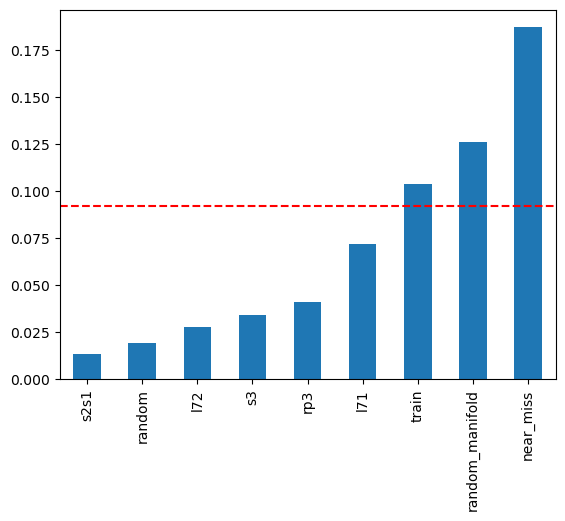

In [27]:
pd.DataFrame(losses).iloc[-1].sort_values().plot.bar()
plt.axhline(0.092, color='red', linestyle='--')

[]

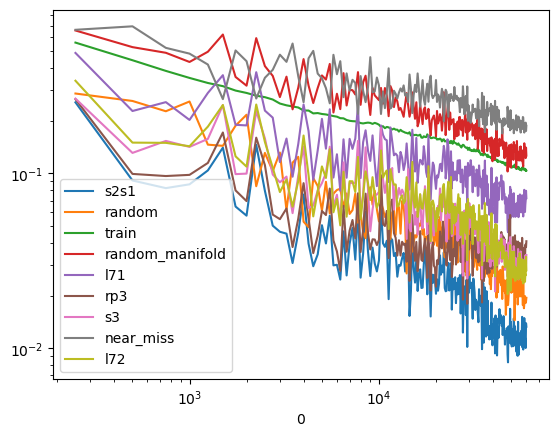

In [21]:
pd.DataFrame(losses).plot()
plt.loglog()